# Data Collection

## Objective

Collect historical stock market data for major technology companies.

## Source

Yahoo Finance API (yfinance)

## Companies

- Apple
- Microsoft
- Nvidia
- Amazon
- Alphabet

## Time Period

2020–2024

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
apple = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


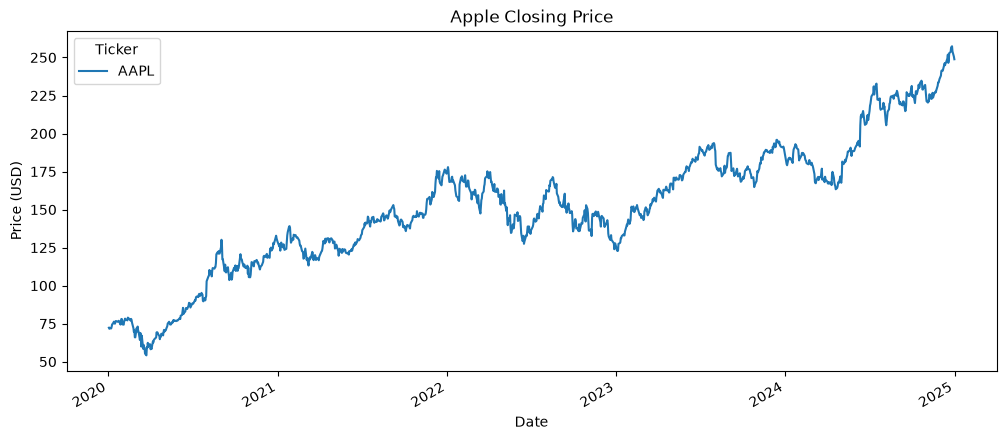

In [3]:
apple["Close"].plot(figsize=(12,5))

plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.show()

In [4]:
companies = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL"
]

In [11]:
import pandas as pd
import yfinance as yf

companies = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL"
]

all_data = []

for ticker in companies:

    print(f"Downloading {ticker}")

    df = yf.download(
        ticker,
        start="2020-01-01",
        end="2025-01-01",
        auto_adjust=False,
        progress=False
    )

    # Remove MultiIndex columns if they exist
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()

    df["Ticker"] = ticker

    all_data.append(df)

master = pd.concat(all_data, ignore_index=True)

master.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2020-01-02,72.333878,75.087502,75.150002,73.797501,74.059998,135480400,AAPL
1,2020-01-03,71.630661,74.357498,75.144997,74.125000,74.287498,146322800,AAPL
2,2020-01-06,72.201416,74.949997,74.989998,73.187500,73.447502,118387200,AAPL
3,2020-01-07,71.861855,74.597504,75.224998,74.370003,74.959999,108872000,AAPL
4,2020-01-08,73.017845,75.797501,76.110001,74.290001,74.290001,132079200,AAPL


In [12]:
master.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='str', name='Price')

In [13]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   Date       6290 non-null   datetime64[s]
 1   Adj Close  6290 non-null   float64      
 2   Close      6290 non-null   float64      
 3   High       6290 non-null   float64      
 4   Low        6290 non-null   float64      
 5   Open       6290 non-null   float64      
 6   Volume     6290 non-null   int64        
 7   Ticker     6290 non-null   str          
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 393.3 KB


In [14]:
master.to_csv(
    "../data/processed/master_stock_data.csv",
    index=False
)